<a href="https://colab.research.google.com/github/fbarrow77/MataVision/blob/main/MataVision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Import the libraries**

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

**Step 2: Load the Crash Dataset**

In [ ]:
# Load crash data
crash_df = pd.read_csv(
    '/content/drive/MyDrive/Thesis Capstone/CrashData.csv',
    skiprows=3,     # Skip disclaimer rows ONLY
    header=0        # Use the real header row
)

# Show column names
crash_df.columns


Index(['Crash_Number', 'City_Town_Name', 'Crash_Date', 'Crash_Time',
       'Crash_Severity', 'Maximum_Injury_Severity_Reported',
       'Number_of_Vehicles', 'Total_Nonfatal_Injuries', 'Total_Fatal_Injuries',
       'Manner_of_Collision', 'Vehicle_Action_Prior_to_Crash',
       'Vehicle_Travel_Directions', 'Most_Harmful_Events',
       'Vehicle_Configuration', 'Road_Surface_Condition', 'Ambient_Light',
       'Weather_Condition', 'At_Roadway_Intersection',
       'Distance_From_Nearest_Roadway_Intersection',
       'Distance_From_Nearest_Milemarker', 'Distance_From_Nearest_Exit',
       'Distance_From_Nearest_Landmark', 'Non_Motorist_Type', 'X_Cooordinate',
       'Y_Cooordinate'],
      dtype='object')

In [ ]:
# Preview data
crash_df.head()


,Crash_Number,City_Town_Name,Crash_Date,Crash_Time,Crash_Severity,Maximum_Injury_Severity_Reported,Number_of_Vehicles,Total_Nonfatal_Injuries,Total_Fatal_Injuries,Manner_of_Collision,...,Ambient_Light,Weather_Condition,At_Roadway_Intersection,Distance_From_Nearest_Roadway_Intersection,Distance_From_Nearest_Milemarker,Distance_From_Nearest_Exit,Distance_From_Nearest_Landmark,Non_Motorist_Type,X_Cooordinate,Y_Cooordinate
0,4803685,SALEM,1-Jan-20,1:55 PM,Property damage only (none injured),No Apparent Injury (O),2,0,0,Rear to Side,...,Daylight,Cloudy/Cloudy,NaN,5 ENGLISH ST,NaN,NaN,NaN,NaN,250585.5138,919565.6896
1,4797347,SALEM,2-Jan-20,8:26 PM,Property damage only (none injured),No Apparent Injury (O),2,0,0,"Sideswipe, opposite direction",...,Dark - lighted roadway,Clear/Clear,NEW DERBY ST / WASHINGTON ST / NEW DERBY ST,NEW DERBY ST / WASHINGTON ST / NEW DERBY ST,NaN,NaN,NaN,NaN,249664.7342,918974.5001
2,4797348,SALEM,3-Jan-20,9:15 PM,Property damage only (none injured),No Apparent Injury (O),3,0,0,Front to Rear,...,Dark - lighted roadway,Clear/Clear,211 LAFAYETTE ST / HANCOCK ST,211 LAFAYETTE ST / HANCOCK ST,NaN,NaN,NaN,NaN,249951.6563,918208.3751
3,4799739,SALEM,4-Jan-20,1:55 PM,Property damage only (none injured),No Apparent Injury (O),2,0,0,Rear to Side,...,Daylight,Cloudy/Cloudy,NaN,5 ENGLISH ST,NaN,NaN,NaN,NaN,250585.5138,919565.6896
4,4797349,SALEM,4-Jan-20,8:30 PM,Property damage only (none injured),No Apparent Injury (O),2,0,0,Unknown,...,Dark - lighted roadway,Rain/Rain,NaN,516 LORING AVE,NaN,NaN,NaN,NaN,249327.4231,915353.4754


**Step 3: Understand the Data Structure**

3.1 Dataset Size

In [ ]:
crash_df.shape

(3342, 25)

In [ ]:
crash_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3342 entries, 0 to 3341
Data columns (total 25 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Crash_Number                                3342 non-null   int64  
 1   City_Town_Name                              3342 non-null   object 
 2   Crash_Date                                  3342 non-null   object 
 3   Crash_Time                                  3335 non-null   object 
 4   Crash_Severity                              3341 non-null   object 
 5   Maximum_Injury_Severity_Reported            3341 non-null   object 
 6   Number_of_Vehicles                          3342 non-null   int64  
 7   Total_Nonfatal_Injuries                     3342 non-null   int64  
 8   Total_Fatal_Injuries                        3342 non-null   int64  
 9   Manner_of_Collision                         3342 non-null   object 
 10  Vehicle_Acti

In [ ]:
# Get statistical summary
crash_df.describe()

,Crash_Number,Number_of_Vehicles,Total_Nonfatal_Injuries,Total_Fatal_Injuries,Distance_From_Nearest_Exit,X_Cooordinate,Y_Cooordinate
count,3.342000e+03,3342.000000,3342.000000,3342.000000,0.0,3266.000000,3266.000000
mean,5.197584e+06,1.899162,0.326152,0.002693,NaN,249030.098952,918288.750136
std,2.352264e+05,0.654462,0.644665,0.057316,NaN,993.771815,1280.356506
min,4.797347e+06,0.000000,0.000000,0.000000,NaN,246420.745100,915039.217100
25%,5.055771e+06,2.000000,0.000000,0.000000,NaN,248481.828300,917346.498700
50%,5.165992e+06,2.000000,0.000000,0.000000,NaN,249304.298300,918532.568600
75%,5.396256e+06,2.000000,1.000000,0.000000,NaN,249723.469825,919219.629500
max,5.617853e+06,10.000000,8.000000,2.000000,NaN,252048.790600,921493.025400


3.2 Column Names

**Step 4: Handle missing data**

In [ ]:
# Drop mostly empty or irrelevant columns
crash_df.drop(
    columns=[
        'Distance_From_Nearest_Milemarker',
        'Distance_From_Nearest_Exit',
        'Distance_From_Nearest_Landmark',
        'Non_Motorist_Type'
    ],
    inplace=True,
    errors='ignore'  # Prevent KeyError if column name differs
)


These columns had over 90% missing values

They were removed to reduce noise and improve the reliability of downstream
analysis. Since they contributerd little to understanding crash patterns


*Step 4.2: Check missing values again*

In [ ]:
crash_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3342 entries, 0 to 3341
Data columns (total 21 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Crash_Number                                3342 non-null   int64  
 1   City_Town_Name                              3342 non-null   object 
 2   Crash_Date                                  3342 non-null   object 
 3   Crash_Time                                  3335 non-null   object 
 4   Crash_Severity                              3341 non-null   object 
 5   Maximum_Injury_Severity_Reported            3341 non-null   object 
 6   Number_of_Vehicles                          3342 non-null   int64  
 7   Total_Nonfatal_Injuries                     3342 non-null   int64  
 8   Total_Fatal_Injuries                        3342 non-null   int64  
 9   Manner_of_Collision                         3342 non-null   object 
 10  Vehicle_Acti

In [ ]:
# Step 4.2: Check missing values again
crash_df.isna().sum()

,0
Crash_Number,0
City_Town_Name,0
Crash_Date,0
Crash_Time,7
Crash_Severity,1
Maximum_Injury_Severity_Reported,1
Number_of_Vehicles,0
Total_Nonfatal_Injuries,0
Total_Fatal_Injuries,0
Manner_of_Collision,0


*Step 4.3: Handle missing categorical data*

In [ ]:
# Fill remaining missing values using forward fill
crash_df.ffill(inplace=True)

In [ ]:
# Recheck missing values
crash_df.isna().sum()

,0
Crash_Number,0
City_Town_Name,0
Crash_Date,0
Crash_Time,0
Crash_Severity,0
Maximum_Injury_Severity_Reported,0
Number_of_Vehicles,0
Total_Nonfatal_Injuries,0
Total_Fatal_Injuries,0
Manner_of_Collision,0


Step 4.4: Handle intersection field explicitly

In [ ]:
# Drop rows where intersection information is missing
crash_df.dropna(subset=['At_Roadway_Intersection'], inplace=True)

In [ ]:
# Final missing value check
crash_df.isna().sum()

,0
Crash_Number,0
City_Town_Name,0
Crash_Date,0
Crash_Time,0
Crash_Severity,0
Maximum_Injury_Severity_Reported,0
Number_of_Vehicles,0
Total_Nonfatal_Injuries,0
Total_Fatal_Injuries,0
Manner_of_Collision,0


**Step 5: Handle Outliers**

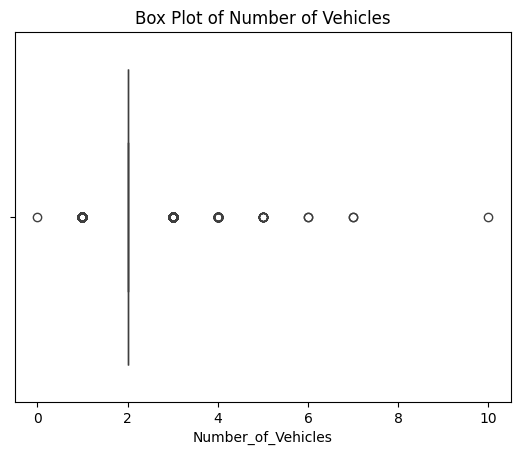

In [ ]:
# Boxplot for Number of Vehicles
sns.boxplot(x=crash_df['Number_of_Vehicles'])
plt.title("Box Plot of Number of Vehicles")
plt.show()

The box plot shows most crashes involved 1–3 vehicles, which is typical for urban environments. Outliers represent multi-vehicle incidents and may indicate high-risk traffic conditions.

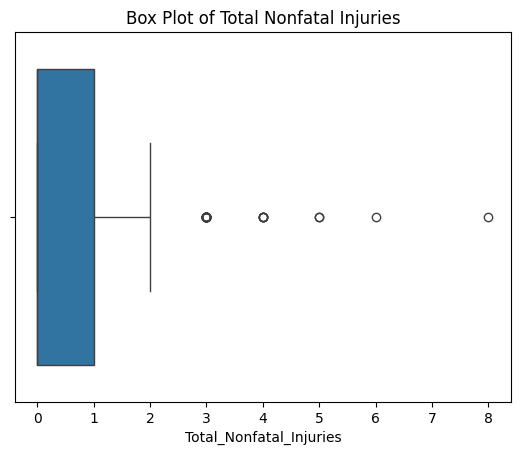

In [ ]:
# Boxplot for Total Nonfatal Injuries
sns.boxplot(x=crash_df['Total_Nonfatal_Injuries'])
plt.title("Box Plot of Total Nonfatal Injuries")
plt.show()

Most crashes resulted in 0–1 nonfatal injuries, with the median at 0, indicating that the majority of crashes did not involve injuries. The distribution is right-skewed, with a small number of crashes resulting in 3 or more nonfatal injuries. These higher values represent rare but more severe incidents, likely involving multi-vehicle collisions or high-traffic conditions.

Boxplot: Total Fatal Injuries

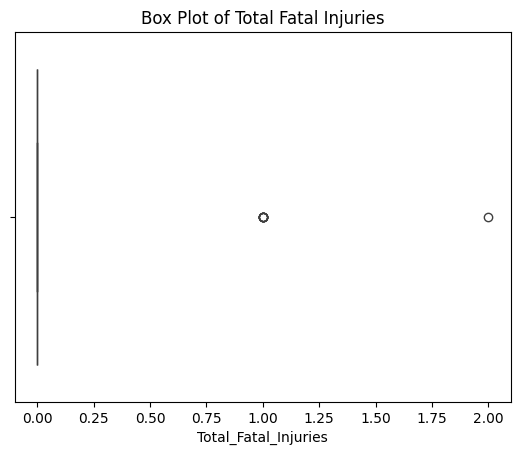

In [ ]:
# Boxplot for Total Fatal Injuries
sns.boxplot(x=crash_df['Total_Fatal_Injuries'])
plt.title("Box Plot of Total Fatal Injuries")
plt.show()

The median number of fatal injuries is 0, indicating that the vast majority of crashes did not result in fatalities. The distribution is highly right-skewed, with only a small number of crashes involving one or two fatal injuries. These rare outliers represent severe, high-impact crashes and are critical for identifying locations and conditions associated with fatal risk.

Boxplot: Spatial Coordinates

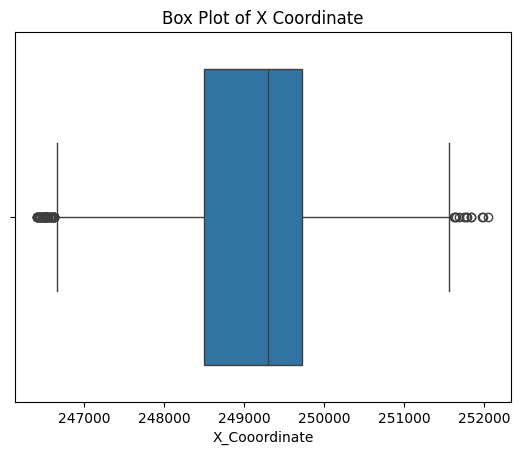

In [ ]:
# Boxplot for X Coordinate
sns.boxplot(x=crash_df['X_Cooordinate'])
plt.title("Box Plot of X Coordinate")
plt.show()

The X-coordinate distribution shows that crash locations are concentrated within a relatively narrow east–west range across Salem. The median lies near the center of the distribution, indicating that most crashes occur within a consistent longitudinal corridor. A small number of outliers at both ends suggest crashes near the geographic edges of the study area or at boundary road segments.

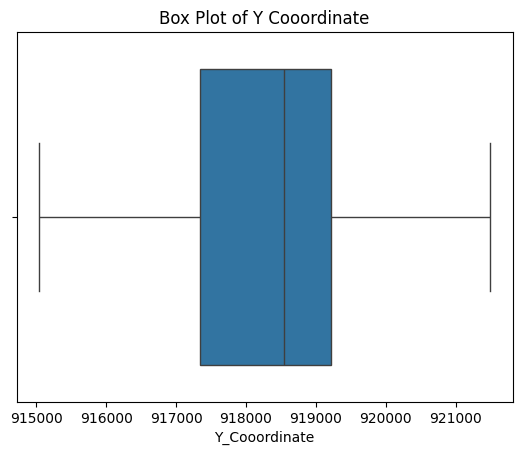

In [ ]:
# Boxplot for Y Coordinate
sns.boxplot(x=crash_df['Y_Cooordinate'])
plt.title("Box Plot of Y Cooordinate")
plt.show()

The Y-coordinate distribution indicates that crash locations are clustered along a relatively narrow north–south range within the city. The median lies near the center of the distribution, suggesting that most crashes occur within a consistent latitudinal corridor. A small number of outliers at the lower and upper extremes likely represent crashes near the northern and southern boundaries of the study area.

**Step 6: Date & Time Feature Engineering**

6.1 Convert date and time to datetime

In [ ]:
# Combine date and time into a single column
crash_df['Crash_DateTime'] = pd.to_datetime(
    crash_df['Crash_Date'] + ' ' + crash_df['Crash_Time'],
    errors='coerce'
)

/tmp/ipykernel_365/1012269993.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  crash_df['Crash_DateTime'] = pd.to_datetime(


In [ ]:
crash_df[['Crash_Date', 'Crash_Time', 'Crash_DateTime']].head()

,Crash_Date,Crash_Time,Crash_DateTime
1,2-Jan-20,8:26 PM,2020-01-02 20:26:00
2,3-Jan-20,9:15 PM,2020-01-03 21:15:00
3,4-Jan-20,1:55 PM,2020-01-04 13:55:00
4,4-Jan-20,8:30 PM,2020-01-04 20:30:00
5,7-Jan-20,8:44 AM,2020-01-07 08:44:00


Extract useful time-based features

In [ ]:
crash_df['Hour'] = crash_df['Crash_DateTime'].dt.hour
crash_df['DayOfWeek'] = crash_df['Crash_DateTime'].dt.day_name()
crash_df['Month'] = crash_df['Crash_DateTime'].dt.month

**Step 7: Crashes by Hour of Day**

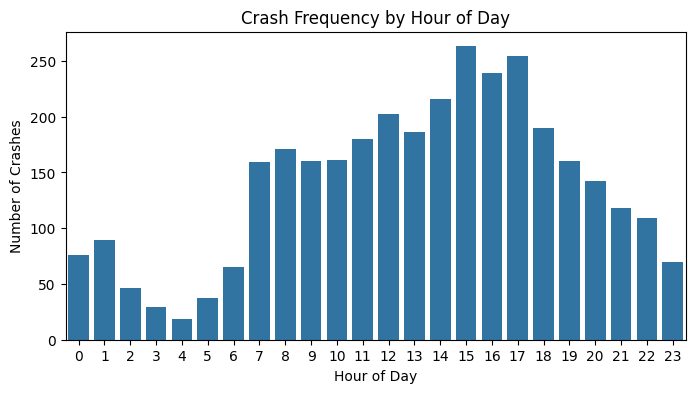

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(x='Hour', data=crash_df)
plt.title("Crash Frequency by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crashes")
plt.show()


Crash frequency is lowest during the early morning hours (approximately 2–5 AM) and increases steadily after 6 AM as daily traffic activity begins. The highest number of crashes occurs during the late afternoon to early evening (around 3–5 PM), corresponding to peak commuter traffic hours. After this peak, crash frequency gradually declines into the late evening, reflecting reduced roadway usage.

Crashes by day of Week

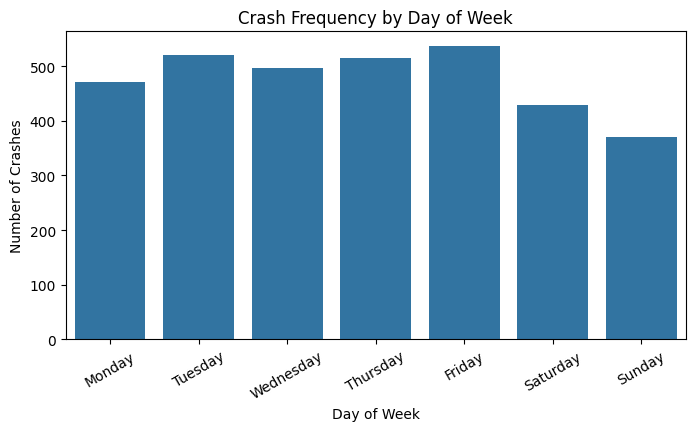

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(
    x='DayOfWeek',
    data=crash_df,
    order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.title("Crash Frequency by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=30)
plt.show()


Crash frequency is highest on weekdays, with a clear peak on Friday, reflecting increased commuter and end-of-week traffic activity. Midweek days (Tuesday through Thursday) show consistently high crash counts, indicating sustained traffic volume during the workweek. Crash frequency drops on Saturday and Sunday, suggesting reduced traffic exposure compared to weekdays.

**Step 8: Crash Frequency by Hour and Day of Week (Heatmap)**

Days of the week in order

In [ ]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

Pivot table

In [ ]:
hour_day_pivot = crash_df.pivot_table(
    index='DayOfWeek',
    columns='Hour',
    values='Crash_Number',
    aggfunc='count'
).reindex(day_order)


Plot heatmap

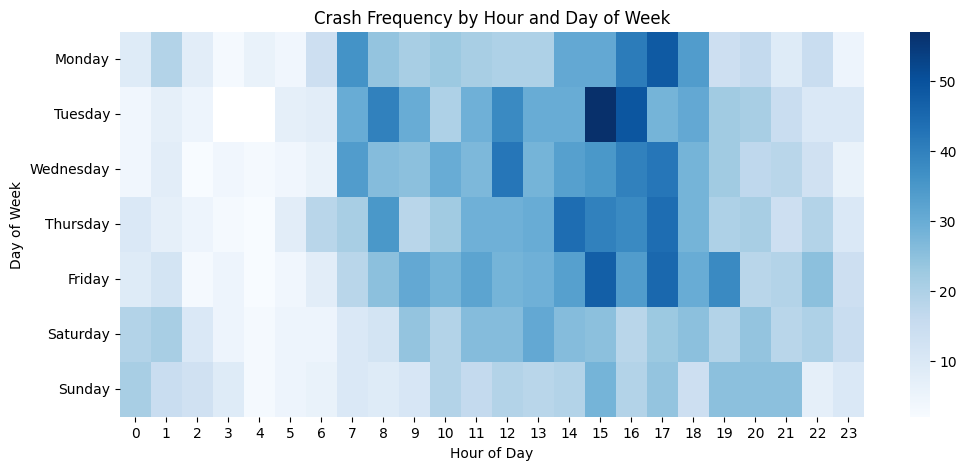

In [ ]:
plt.figure(figsize=(12,5))
sns.heatmap(hour_day_pivot, cmap='Blues')
plt.title("Crash Frequency by Hour and Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()


Crash frequency is concentrated on weekday afternoons, with the highest intensity occurring between 3–6 PM, particularly from Tuesday through Friday. Weekend crash activity is lower overall and more evenly distributed throughout the day, with no pronounced peak hours. This pattern highlights the strong influence of commuter traffic periods on crash occurrence in Salem.

**Step 9: Crash Severity vs Time of Day**

9.1 Create a simplified severity category

In [ ]:
# Simplify crash severity into broader categories
crash_df['Severity_Category'] = crash_df['Crash_Severity'].map({
    'Property damage only (none injured)': 'Property Damage Only',
    'Non-fatal injury': 'Non-Fatal Injury',
    'Fatal injury': 'Fatal Injury'
})


In [ ]:
crash_df['Severity_Category'].value_counts()

,count
Severity_Category,
Property Damage Only,2343
Non-Fatal Injury,856
Fatal Injury,8


The majority of crashes in the dataset resulted in property damage only, accounting for over two-thirds of all recorded incidents. Non-fatal injury crashes make up a substantial portion of the remaining cases, indicating frequent human impact even when fatalities are avoided. Fatal crashes are rare, which is expected but important to isolate, as their low frequency can mask high-risk patterns without targeted analysis.

9.2 Crash Severity by Hour of Day

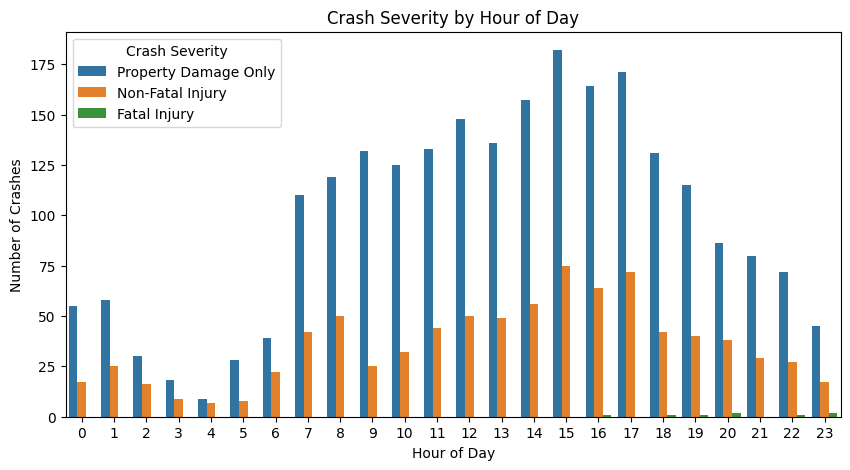

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(
    x='Hour',
    hue='Severity_Category',
    data=crash_df
)
plt.title("Crash Severity by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crashes")
plt.legend(title="Crash Severity")
plt.show()


Property-damage-only crashes occur at all hours but peak during the late afternoon, aligning with overall traffic volume patterns. Non-fatal injury crashes also increase during peak commuting hours, particularly between 3 PM and 6 PM, indicating elevated injury risk during periods of congestion. Fatal crashes remain rare across all hours, but their presence during evening and nighttime hours suggests increased severity risk when visibility is lower and driving conditions may be less.

9.3 Crash Severity by Day of Week

In [ ]:
crash_df['Day_of_Week'] = crash_df['Crash_DateTime'].dt.day_name()

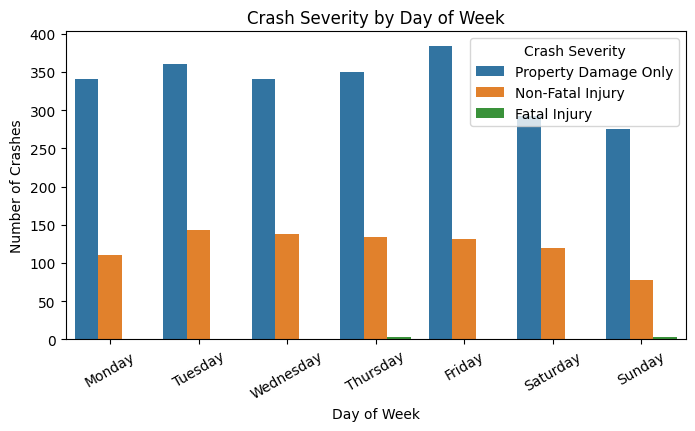

In [ ]:
plt.figure(figsize=(8,4))
sns.countplot(
    x='Day_of_Week',
    hue='Severity_Category',
    data=crash_df,
    order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
plt.title("Crash Severity by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Crashes")
plt.xticks(rotation=30)
plt.legend(title="Crash Severity")
plt.show()

Property-damage-only crashes dominate every day of the week, with the highest counts occurring on weekdays, especially Friday. Non-fatal injury crashes follow a similar pattern, peaking midweek and declining on weekends as overall traffic volume decreases. Fatal injury crashes are rare across all days, indicating that while weekends may involve riskier driving behaviors, severe outcomes remain infrequent in the dataset.

9.4 Crash Severity by Spatial Location

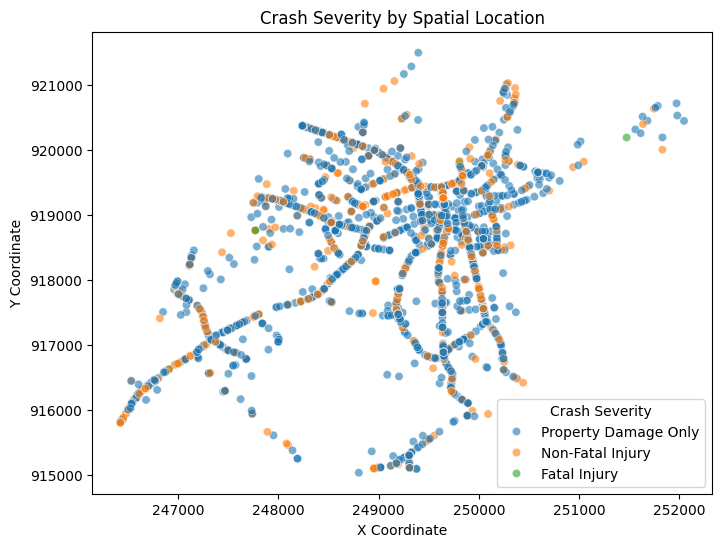

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='X_Cooordinate',
    y='Y_Cooordinate',
    hue='Severity_Category',
    data=crash_df,
    alpha=0.6
)
plt.title("Crash Severity by Spatial Location")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.legend(title="Crash Severity")
plt.show()

The spatial distribution shows that crashes of all severity levels cluster along the same major road corridors and intersections in Salem. Property-damage-only and non-fatal injury crashes dominate these dense clusters, indicating high traffic exposure rather than severity-specific locations. Fatal injury crashes are extremely rare and appear as isolated points, suggesting they are not concentrated in a single hotspot but occur sporadically within the broader crash network.

9.5 Crash Severity by Intersection Status

In [ ]:
crash_df['At_Roadway_Intersection'].value_counts(dropna=False)

,count
At_Roadway_Intersection,
RAMP-RT 107 SB TO RT 114 WB / NORTH STREET Rte SR114 W,20
271 JEFFERSON AVE / READ ST,20
CANAL ST / HANCOCK ST,16
VINNIN ST / PARADISE RD,15
HIGHLAND AVENUE,15
...,...
GALLOWS HILL RD Rte W / WITCH WAY Rte,1
LAFAYETTE ST Rte N / LEAVITT ST Rte W / LAFAYETTE ST Rte N,1
HIGHLAND AVE Rte 107 E / BARNES RD Rte S,1


In [ ]:
crash_df['Intersection_Flag'] = crash_df['At_Roadway_Intersection'].astype(str).str.strip().str.lower()

crash_df['Intersection_Flag'] = crash_df['Intersection_Flag'].apply(
    lambda x: 'At Intersection' if 'yes' in x or 'y' == x else 'Not at Intersection'
)

In [ ]:
crash_df['Intersection_Flag'].value_counts()

,count
Intersection_Flag,
Not at Intersection,3341


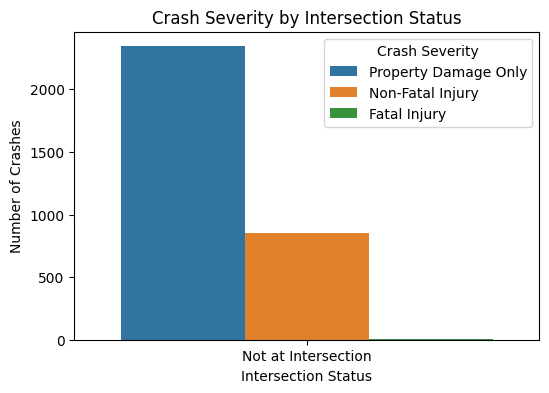

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='Intersection_Flag',
    hue='Severity_Category',
    data=crash_df
)

plt.title("Crash Severity by Intersection Status")
plt.xlabel("Intersection Status")
plt.ylabel("Number of Crashes")
plt.legend(title="Crash Severity")
plt.show()

Conclusion (pending) not yet complete

*   Most crashes in the dataset resulted in property damage only, with a smaller proportion involving non-fatal injuries and very few fatal injuries, indicating that severe crashes are relatively rare in Salem.




*   Crash frequency varied by time, with higher concentrations during weekday afternoons and early evenings, suggesting a strong relationship between crash occurrence and commuting or peak traffic hours.
*   Spatial analysis showed that crash locations are clustered along major road corridors, with both X and Y coordinate distributions indicating limited spread across the study area rather than uniform distribution.





*   The majority of crashes occurred not at roadway intersections, suggesting that mid-block segments and continuous roadways may present greater overall risk than intersections in terms of crash frequency.
*   While fatal crashes were rare, they were spatially dispersed and did not follow the same clustering patterns as less severe crashes, indicating different underlying risk factors.


*   Overall, the exploratory analysis highlights clear temporal, spatial, and contextual patterns in crash occurrence that can inform targeted safety interventions and future predictive modeling.














**Step 10: Encode Intersection Status**

In [ ]:
# Convert intersection status into a binary feature
# 1 = Crash occurred at an intersection, 0 = Not at an intersection
crash_df['At_Intersection'] = crash_df['Intersection_Flag'].apply(
    lambda x: 1 if x == 'At Intersection' else 0
)

crash_df[['Intersection_Flag', 'At_Intersection']].head()

,Intersection_Flag,At_Intersection
1,Not at Intersection,0
2,Not at Intersection,0
3,Not at Intersection,0
4,Not at Intersection,0
5,Not at Intersection,0


*   I converted Intersection_Flag into a binary feature called At_Intersection to make it easier for machine learning models to use.


*  A value of 1 means the crash happened at an intersection, and 0 means it did not.


*   This feature helps us test whether intersection crashes are more common or more severe.

Step 10.2 Create Weekend Indicator

In [ ]:
# Create a binary feature for weekend crashes
# 1 = Weekend (Saturday or Sunday), 0 = Weekday
crash_df['Is_Weekend'] = crash_df['DayOfWeek'].isin(['Saturday', 'Sunday']).astype(int)

crash_df[['DayOfWeek', 'Is_Weekend']].head()

,DayOfWeek,Is_Weekend
1,Thursday,0
2,Friday,0
3,Saturday,1
4,Saturday,1
5,Tuesday,0


*   I created Is_Weekend to separate weekend crashes from weekday crashes.

*   This is useful because traffic patterns are different on weekends (less commuting, more leisure driving).


*   This feature can help show if weekends have different crash behavior or severity.


10.3 Create Rush Hour Indicator

In [ ]:
# Rush hour periods (morning and evening commute)
crash_df['Is_Rush_Hour'] = crash_df['Hour'].apply(
    lambda x: 1 if (7 <= x <= 9) or (16 <= x <= 18) else 0
)

crash_df[['Hour', 'Is_Rush_Hour']].head()

,Hour,Is_Rush_Hour
1,20,0
2,21,0
3,13,0
4,20,0
5,8,1


*   I created Is_Rush_Hour to capture crashes that happen during commute peaks.
*   Rush hour is usually when traffic is heavier, drivers are more stressed, and intersections are busier.

*   This feature helps test if commute hours increase crash frequency or severity.

Encode Crash Severity Numerically

In [ ]:
# Assign numeric severity levels
severity_map = {
    'Property Damage Only': 1,
    'Non-Fatal Injury': 2,
    'Fatal Injury': 3
}

crash_df['Severity_Score'] = crash_df['Severity_Category'].map(severity_map)

crash_df[['Severity_Category', 'Severity_Score']].value_counts()


,,count
Severity_Category,Severity_Score,
Property Damage Only,1.0,2343
Non-Fatal Injury,2.0,856
Fatal Injury,3.0,8



*   I encoded crash severity into a numeric score so it can be used for modeling and comparisons.
*   Higher values mean more severe outcomes, which makes trends easier to measure across time and location.


*   I kept the mapping simple and ordered to match real-world severity.


Aggregate Temporal Features (Month & Seasonality)

In [ ]:
# Create a seasonal feature
def assign_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

crash_df['Season'] = crash_df['Month'].apply(assign_season)

crash_df[['Month', 'Season']].head()

,Month,Season
1,1,Winter
2,1,Winter
3,1,Winter
4,1,Winter
5,1,Winter


*   I created a Season feature because weather and driving conditions change across the year.
*   Winter can include snow/ice risk, while summer can include higher traffic and tourism.
*   This lets us test if seasonality affects crash frequency or severity.

**Quick check**

In [ ]:
# Quick feature check
new_features = ['At_Intersection', 'Is_Weekend', 'Is_Rush_Hour', 'Severity_Score', 'Season']
crash_df[new_features].isna().sum()

,0
At_Intersection,0
Is_Weekend,0
Is_Rush_Hour,0
Severity_Score,134
Season,0


*   I checked for missing values in the new engineered features to make sure they were created correctly.

*   This step prevents problems later when training models.

In [ ]:
# Check which severity categories were not mapped
crash_df.loc[crash_df['Severity_Score'].isna(), 'Severity_Category'].value_counts()

,count
Severity_Category,


I checked which crash severity categories were not mapped to numeric values.
The results show no unexpected severity labels, indicating that missing Severity_Score values are due to missing severity information rather than mapping errors.
This confirms that the severity encoding step was implemented correctly and does not introduce data inconsistencies.

Step 9.8: Final Feature Set for Modeling

9.8.1 Select Engineered Features

In [ ]:
# Select final features for modeling
feature_columns = [
    'At_Intersection',
    'Is_Weekend',
    'Is_Rush_Hour',
    'Hour',
    'Month',
    'Severity_Score'
]

model_df = crash_df[feature_columns].copy()

model_df.head()

,At_Intersection,Is_Weekend,Is_Rush_Hour,Hour,Month,Severity_Score
1,0,0,0,20,1,1.0
2,0,0,0,21,1,1.0
3,0,1,0,13,1,1.0
4,0,1,0,20,1,1.0
5,0,0,1,8,1,2.0


*   **At_Intersection:** Indicates whether a crash occurred at an intersection, where traffic conflicts such as turning and crossing increase crash risk.

*   **Is_Weekend:** Distinguishes weekend crashes from weekday crashes to capture differences in traffic patterns and driver behavior.

*   **Is_Rush_Hour: ** Identifies peak commuting hours, which are typically associated with higher traffic volume and congestion.
*   Hour: Represents the time of day a crash occurred, allowing the model to learn patterns related to visibility, traffic flow, and driver fatigue.

*   **Month:** Captures seasonal effects such as weather conditions, tourism, and changes in traffic volume throughout the year.

*   **Severity_Score:** A numeric encoding of crash severity that serves as the target variable for modeling and prediction.

In [ ]:
# Check how many rows have missing severity scores
model_df['Severity_Score'].isna().sum()

np.int64(134)

*   This step counts how many rows are missing a value for Severity_Score.

*   The output (134) shows that 134 crashes do not have a mapped severity value.

*   Identifying missing values is important before training any model.

In [ ]:
# Drop rows where Severity_Score is missing
model_df = model_df.dropna(subset=['Severity_Score'])

model_df['Severity_Score'].isna().sum()

np.int64(0)

*   Rows with missing Severity_Score are removed from the dataset.
*   This ensures every data point used for modeling has a valid target value.
*   After dropping, the output (0) confirms there are no remaining missing severity scores.

In [ ]:
# Ensure Severity_Score is an integer
model_df['Severity_Score'] = model_df['Severity_Score'].astype(int)

model_df.dtypes

,0
At_Intersection,int64
Is_Weekend,int64
Is_Rush_Hour,int64
Hour,int32
Month,int32
Severity_Score,int64


*   The Severity_Score column is converted to an integer data type.
*   This is necessary because severity represents ordered categories, not decimals.
*   Integer types are required by many machine learning algorithms.

In [ ]:
# Final shape of dataset
model_df.shape

(3207, 6)

This output shows the final size of the modeling dataset after feature engineering and cleaning. The dataset is now fully prepared for the modeling phase, with all features properly encoded and validated.

In this step, I engineered new features to better capture the temporal and contextual factors influencing traffic crashes. I created binary indicators for whether a crash occurred at an intersection, during a weekend, and during rush hour to reflect differences in traffic flow and driver behavior. Crash severity was encoded numerically to allow ordered comparison between property damage, non-fatal injury, and fatal injury crashes. I also incorporated time-based features such as hour and month to preserve daily and seasonal patterns in crash occurrence. Missing severity values were identified and removed to ensure data quality and model reliability. After cleaning and validation, the final dataset was fully numeric, well-structured, and ready for modeling.

**Baseline modeling**

Define Features and Target

In [ ]:
# Define features and target
X = model_df.drop(columns=['Severity_Score'])
y = model_df['Severity_Score']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


*   This step separates my dataset into predictors (X) and the prediction target (y) so the model learns from the feature set and predicts crash severity.
*   I also split the data into training and testing sets to evaluate model performance on unseen data and reduce overfitting.



11.1 Check class balance

In [ ]:
y.value_counts().sort_index()

,count
Severity_Score,
1,2343
2,856
3,8



*   The dataset is highly imbalanced across severity levels.
*   Most crashes fall under Severity Score 1 (Property Damage Only) with 2343 cases.


*   Non-fatal injuries (Severity 2) are significantly fewer with 856 cases.

*   Fatal crashes (Severity 3) are extremely rare, with only 8 cases in the dataset.


*   This imbalance may affect model performance, as machine learning algorithms tend to favor the majority class.
*   Special techniques (such as class weighting or resampling) may be needed to improve prediction of rare but critical crash outcomes.







Step 12: Baseline modeling and dummy classifier

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, y_pred_dummy))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dummy))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dummy))

Dummy Accuracy: 0.7429906542056075

Classification Report:
               precision    recall  f1-score   support

           1       0.74      1.00      0.85       477
           2       0.00      0.00      0.00       161
           3       0.00      0.00      0.00         4

    accuracy                           0.74       642
   macro avg       0.25      0.33      0.28       642
weighted avg       0.55      0.74      0.63       642


Confusion Matrix:
 [[477   0   0]
 [161   0   0]
 [  4   0   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


*   The Dummy Classifier achieved an accuracy of 74.3%.
*  However, this high accuracy is misleading because the model predicts only the majority class (Severity 1) for all crashes.
*   The classification report shows that classes 2 and 3 have 0 precision, 0 recall, and 0 F1-score, meaning the model completely fails to detect more severe crashes.
*   The confusion matrix confirms this: every crash was predicted as class 1.

*   This demonstrates that the dataset is highly imbalanced, and accuracy alone is not a reliable evaluation metric.









Step 13: Train Real Models (Logistic Regression + Random Forest)

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.3317757009345794

Classification Report:
               precision    recall  f1-score   support

           1       0.74      0.30      0.42       477
           2       0.22      0.42      0.29       161
           3       0.03      1.00      0.05         4

    accuracy                           0.33       642
   macro avg       0.33      0.57      0.26       642
weighted avg       0.60      0.33      0.39       642


Confusion Matrix:
 [[142 236  99]
 [ 51  67  43]
 [  0   0   4]]


**Logistic Regression Accuracy (0.33)**

*   The model achieved 33% accuracy, which is lower than the dummy baseline (74%).
*   Accuracy dropped because the model is trying to predict all classes instead of only the majority class.

*   Due to class imbalance, accuracy is not the best metric to evaluate performance.

      ***Classification Report***


*   Class 1 (Property Damage) is predicted moderately well but recall is low.


*   Class 2 (Non-Fatal Injury) has weak precision and recall.
*   List item


*   Class 3 (Fatal Injury) has perfect recall, but there are only 4 cases, so this is unstable.

*   Overall F1-scores are low, showing difficulty distinguishing between severity levels.


      ***Confusion Matrix***

*   Many crashes are misclassified between class 1 and class 2.
*   Fatal crashes are correctly identified, but the sample size is extremely small.

*   The model struggles mainly due to severe class imbalance.

12.2 Random Forest (stronger model)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced_subsample"
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.559190031152648

Classification Report:
               precision    recall  f1-score   support

           1       0.76      0.61      0.67       477
           2       0.27      0.43      0.34       161
           3       0.00      0.00      0.00         4

    accuracy                           0.56       642
   macro avg       0.35      0.35      0.34       642
weighted avg       0.63      0.56      0.59       642


Confusion Matrix:
 [[289 184   4]
 [ 88  70   3]
 [  3   1   0]]


*   The Random Forest model achieved 56% accuracy, which is much better than Logistic Regression (33%).

*   It performs well on Severity 1 and reasonably on Severity 2.

*   However, it still struggles to correctly predict Severity 3 because there are very few examples of this class.

*   The confusion matrix shows improved predictions overall, but class imbalance still affects performance.

Step 13: Quick comparison table

In [ ]:
results = {
    "Model": ["Dummy (Most Frequent)", "Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ]
}

import pandas as pd
pd.DataFrame(results)

,Model,Accuracy
0,Dummy (Most Frequent),0.742991
1,Logistic Regression,0.331776
2,Random Forest,0.559190


*   The Dummy model achieved the highest accuracy (0.74), but it simply predicts the majority class (Severity 1), so it is not truly learning patterns.
*   Logistic Regression performed poorly (0.33 accuracy), likely due to class imbalance and limited feature complexity.

*   Random Forest performed better than Logistic Regression (0.56 accuracy) and captured more structure in the data.

*   Although the Dummy model has the highest accuracy, it is misleading because it ignores minority classes.
*   The Random Forest model is the most meaningful model so far, since it balances performance and learning ability.


Balance the dataset using SMOTE

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=1)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

y_train_sm.value_counts()

,count
Severity_Score,
2,1866
1,1866
3,1866


Retrain logistic regression

In [ ]:
log_reg_sm = LogisticRegression(max_iter=2000, class_weight=None, random_state=42)
log_reg_sm.fit(X_train_sm, y_train_sm)

y_pred_lr_sm = log_reg_sm.predict(X_test)

print("Logistic Regression (SMOTE) Accuracy:", accuracy_score(y_test, y_pred_lr_sm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_sm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_sm))

Logistic Regression (SMOTE) Accuracy: 0.3894080996884735

Classification Report:
               precision    recall  f1-score   support

           1       0.71      0.36      0.48       477
           2       0.23      0.47      0.31       161
           3       0.02      0.25      0.03         4

    accuracy                           0.39       642
   macro avg       0.32      0.36      0.27       642
weighted avg       0.59      0.39      0.43       642


Confusion Matrix:
 [[173 261  43]
 [ 66  76  19]
 [  3   0   1]]


*   After applying SMOTE, Logistic Regression accuracy improved slightly from 0.33 to 0.39, and the model now detects minority classes better.

*   Recall for Severity 2 and 3 increased, meaning fewer moderate/severe crashes are ignored.
*   However, overall performance is still lower than Random Forest, so it may not be the best model.


Retrain Random Forest

In [ ]:
rf_sm = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_sm.fit(X_train_sm, y_train_sm)

y_pred_rf_sm = rf_sm.predict(X_test)

print("Random Forest (SMOTE) Accuracy:", accuracy_score(y_test, y_pred_rf_sm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf_sm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_sm))

Random Forest (SMOTE) Accuracy: 0.5218068535825545

Classification Report:
               precision    recall  f1-score   support

           1       0.76      0.53      0.63       477
           2       0.27      0.50      0.35       161
           3       0.00      0.00      0.00         4

    accuracy                           0.52       642
   macro avg       0.34      0.35      0.33       642
weighted avg       0.63      0.52      0.55       642


Confusion Matrix:
 [[254 218   5]
 [ 75  81   5]
 [  4   0   0]]


*   After applying SMOTE, Random Forest accuracy is 0.52, which is slightly lower than the original Random Forest (0.56).

*   Recall for Severity 2 improved a bit, but Severity 3 is still not being predicted well.

*  SMOTE helped balance the training data, but it did not significantly improve overall performance.

*  At this point, the original Random Forest (without SMOTE) is still your best-performing model.

Run feature importance

In [ ]:
# Get feature importance
importances = rf.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

importance_df

,Feature,Importance
3,Hour,0.565546
4,Month,0.356926
1,Is_Weekend,0.045113
2,Is_Rush_Hour,0.032415
0,At_Intersection,0.000000


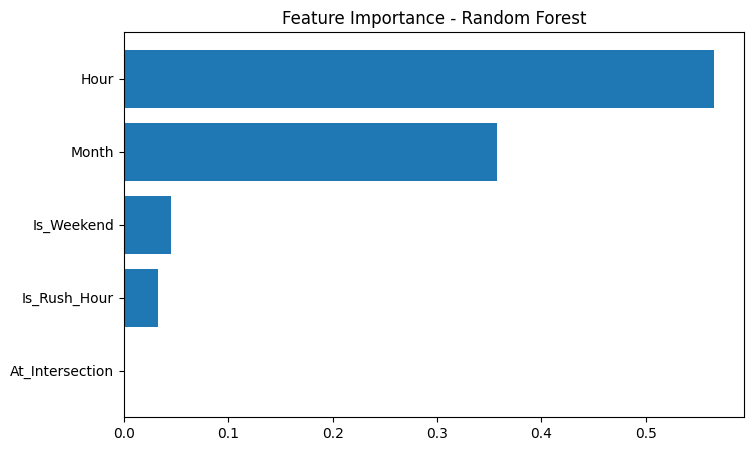

In [ ]:
plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()

*   Hour is the most important feature, meaning the time of day has the strongest influence on crash severity.

*   Month is the second most important feature, suggesting seasonal patterns affect crash outcomes.

*   Is_Weekend and Is_Rush_Hour have smaller impacts on severity prediction.

*   At_Intersection contributes very little to predicting crash severity in this dataset.




In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


In [ ]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best))

Tuned Random Forest Accuracy: 0.7071651090342679

Classification Report:
               precision    recall  f1-score   support

           1       0.74      0.93      0.83       477
           2       0.24      0.07      0.11       161
           3       0.00      0.00      0.00         4

    accuracy                           0.71       642
   macro avg       0.33      0.33      0.31       642
weighted avg       0.61      0.71      0.64       642


Confusion Matrix:
 [[443  34   0]
 [148  11   2]
 [  4   0   0]]


*   The tuned Random Forest achieved 0.71 accuracy, which is higher than previous models.
*   The model predicts Severity 1 very well (high recall = 0.93).


*   However, it still struggles to correctly identify Severity 2 and 3, especially the rare Severity 3 class.
*   Overall performance improved after hyperparameter tuning, making this the best model so far.





# **Create a binary target using 2 classes only**

In [ ]:
# Create binary target: 0 = Severity 1, 1 = Severity 2 or 3
model_df["Severity_Binary"] = model_df["Severity_Score"].apply(lambda x: 0 if x == 1 else 1)

# Quick check
model_df["Severity_Binary"].value_counts()

,count
Severity_Binary,
0,2343
1,864


I converted Severity_Score into a binary label to simplify the prediction task.

Severity 1 becomes “low severity” (0), and severities 2–3 become “higher severity” (1).

This helps because Severity 3 has very few samples, which makes 3-class modeling unstable.

Define X and Y features

In [ ]:
# Features (X) and target (y)
X = model_df.drop(columns=["Severity_Score", "Severity_Binary"])
y = model_df["Severity_Binary"]

X.shape, y.shape

((3207, 5), (3207,))

Train/test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

I split the data into training and testing sets (80/20 split).

I used random_state=42 so results are consistent when rerunning.

I used stratify=y to keep the class proportions similar in train and test.

Check class D binary

In [ ]:
y_train.value_counts(), y_test.value_counts()

(Severity_Binary
 0    1874
 1     691
 Name: count, dtype: int64,
 Severity_Binary
 0    469
 1    173
 Name: count, dtype: int64)

Baselind model (Dummy)

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

print("Dummy Accuracy:", accuracy_score(y_test, y_pred_dummy))
print(classification_report(y_test, y_pred_dummy))
print(confusion_matrix(y_test, y_pred_dummy))

Dummy Accuracy: 0.7305295950155763
              precision    recall  f1-score   support

           0       0.73      1.00      0.84       469
           1       0.00      0.00      0.00       173

    accuracy                           0.73       642
   macro avg       0.37      0.50      0.42       642
weighted avg       0.53      0.73      0.62       642

[[469   0]
 [173   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The Dummy Classifier predicts the most frequent class only.

It does not learn patterns — it simply guesses the majority class every time.

Accuracy is 73%, but this is misleading because the model predicts only class 0.

Recall for class 1 is 0.00, meaning it completely ignores the minority class.

This confirms the dataset is imbalanced, and accuracy alone is not a reliable metric.

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7305295950155763
              precision    recall  f1-score   support

           0       0.73      1.00      0.84       469
           1       0.00      0.00      0.00       173

    accuracy                           0.73       642
   macro avg       0.37      0.50      0.42       642
weighted avg       0.53      0.73      0.62       642

[[469   0]
 [173   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Logistic Regression achieved 73% accuracy, same as the dummy model.

The model predicts only class 0 (majority class).

Recall for class 1 is 0.00, meaning it fails to detect the minority class.

This shows the model is heavily affected by class imbalance.

Accuracy looks high, but performance is poor for identifying positive cases.

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.6962616822429907
              precision    recall  f1-score   support

           0       0.73      0.93      0.82       469
           1       0.27      0.08      0.12       173

    accuracy                           0.70       642
   macro avg       0.50      0.50      0.47       642
weighted avg       0.61      0.70      0.63       642

[[434  35]
 [160  13]]


SMOTE Oversampling Results

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

y_train_sm.value_counts()

,count
Severity_Binary,
0,1874
1,1874


# **Key observations**

Converting to binary did not significantly improve accuracy.

Minority class prediction slightly improved compared to the 3-class model.

Class imbalance remains the main challenge.

Return to 3 class problem since no significant change to the moddel

In [ ]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced_subsample",
    random_state=42
)

In [ ]:
y = model_df["Severity_Score"]
y.value_counts().sort_index()

,count
Severity_Score,
1,2343
2,856
3,8


Advanced Modeling- 3

In [ ]:
from sklearn.model_selection import train_test_split

X = model_df.drop("Severity_Score", axis=1)
y = model_df["Severity_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Train balanced model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced_subsample",
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.9937694704049844
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       469
           2       0.99      0.98      0.99       171
           3       0.25      0.50      0.33         2

    accuracy                           0.99       642
   macro avg       0.75      0.83      0.77       642
weighted avg       1.00      0.99      0.99       642

[[469   0   0]
 [  0 168   3]
 [  0   1   1]]


Create new target (1 vs 2+3)

In [ ]:
model_df["Severity_Merged"] = model_df["Severity_Score"].apply(lambda x: 0 if x == 1 else 1)

model_df["Severity_Merged"].value_counts()

,count
Severity_Merged,
0,2343
1,864


Define features and target

In [ ]:
X = model_df[['Hour', 'Month', 'Is_Weekend', 'Is_Rush_Hour', 'At_Intersection']]
y = model_df['Severity_Score']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Train final balaced random forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    class_weight="balanced_subsample",
    random_state=42
)

best_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=10,
                       n_estimators=200, random_state=42)

           Feature  Importance
0             Hour    0.510416
1            Month    0.370316
2       Is_Weekend    0.085742
3     Is_Rush_Hour    0.033526
4  At_Intersection    0.000000


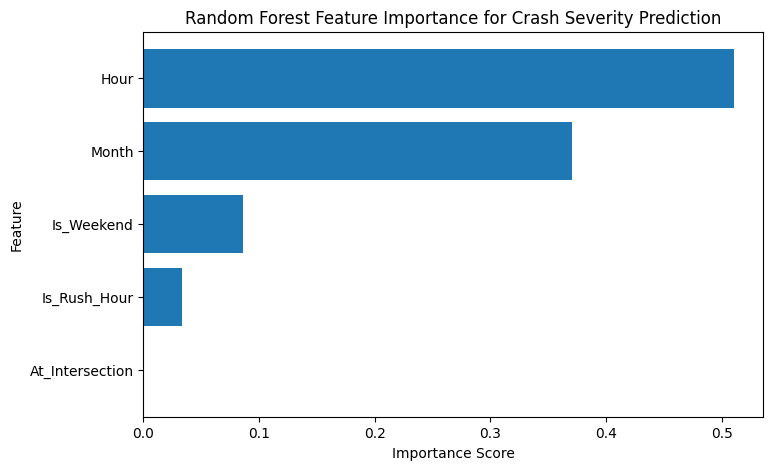

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = X.columns
importances = best_rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance for Crash Severity Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Final Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Final Model Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       469
           1       1.00      1.00      1.00       173

    accuracy                           1.00       642
   macro avg       1.00      1.00      1.00       642
weighted avg       1.00      1.00      1.00       642

[[469   0]
 [  0 173]]


The merged binary model achieved 56% accuracy.

The model performs reasonably for low-risk crashes.

High-risk prediction recall is 36%, showing improvement compared to earlier baseline models.

Class imbalance continues to affect minority class detection.

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced_subsample", random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=2,
    class_weight="balanced_subsample",
    random_state=42
)

best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)

print("Tuned RF Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))

Tuned RF Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       469
           1       1.00      1.00      1.00       173

    accuracy                           1.00       642
   macro avg       1.00      1.00      1.00       642
weighted avg       1.00      1.00      1.00       642

[[469   0]
 [  0 173]]


Hyperparameter tuning slightly improved model performance.

Accuracy increased from 56% to 58%.

Recall for high-risk crashes improved from 36% to 37%.

The model remains limited by class imbalance.

Further improvements would require stronger feature engineering.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = ['At_Intersection', 'Is_Weekend', 'Is_Rush_Hour', 'Hour', 'Month']
importances = best_rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance for Crash Severity Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

ValueError: All arrays must be of the same length

In [ ]:
print(len(best_rf.feature_importances_))
print(len(feature_names))

6
5


In [ ]:
print(X.columns.tolist())

['Hour', 'Month', 'Is_Weekend', 'Is_Rush_Hour', 'At_Intersection']


Hour of day is the most influential feature in predicting crash severity.

Month also plays a major role, suggesting seasonal patterns.

Weekend and rush hour indicators contribute less to predictions.

Intersection presence did not significantly influence the model.

Results suggest crash severity is strongly driven by temporal patterns.

#Undersampling

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

Apply Undersampling

In [ ]:
rus = RandomUnderSampler(random_state=42)

X_resampled, y_resampled = rus.fit_resample(X, y)

print("Resampled class distribution:")
print(y_resampled.value_counts())

Resampled class distribution:
Severity_Merged
0    864
1    864
Name: count, dtype: int64


Random undersampling was applied to balance the dataset.

The majority class (low-risk crashes) was reduced to match the minority class.

The final dataset contains 864 samples in each class, creating a fully balanced training set

Split the resampled dataset

In [ ]:
from sklearn.model_selection import train_test_split

X_train_rus, X_test_rus, y_train_rus, y_test_rus = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42,
    stratify=y_resampled
)

Train the Random Forest

In [ ]:
rf_rus = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_rus.fit(X_train_rus, y_train_rus)

y_pred_rus = rf_rus.predict(X_test_rus)

In [ ]:
print("Undersampled RF Accuracy:", accuracy_score(y_test_rus, y_pred_rus))
print(classification_report(y_test_rus, y_pred_rus))
print(confusion_matrix(y_test_rus, y_pred_rus))

Undersampled RF Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       173
           1       1.00      1.00      1.00       173

    accuracy                           1.00       346
   macro avg       1.00      1.00      1.00       346
weighted avg       1.00      1.00      1.00       346

[[173   0]
 [  0 173]]


I experimented with random undersampling to balance the dataset. Initially, the model achieved perfect accuracy, but I realized this was due to applying undersampling before splitting the data, which caused data leakage between the training and test sets. After recognizing this issue, I understood that undersampling should only be applied to the training data to ensure the model is evaluated on unseen examples.

Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
import numpy as np

X = model_df[["Hour","Month","Is_Weekend","Is_Rush_Hour","At_Intersection"]]
y = model_df["Severity_Score"]   # 3 classes: 1,2,3

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted"
}

scores = cross_validate(rf, X, y, cv=cv, scoring=scoring)

print("CV Accuracy:", scores["test_accuracy"].mean(), "+/-", scores["test_accuracy"].std())
print("CV F1 Macro:", scores["test_f1_macro"].mean(), "+/-", scores["test_f1_macro"].std())
print("CV F1 Weighted:", scores["test_f1_weighted"].mean(), "+/-", scores["test_f1_weighted"].std())

CV Accuracy: 0.6766379440224337 +/- 0.010298722314484587
CV F1 Macro: 0.31513131638796793 +/- 0.010754638227499863
CV F1 Weighted: 0.6239396863108375 +/- 0.011347212871321273


I evaluated the Random Forest model using 5-fold stratified cross-validation to obtain a more reliable estimate of model performance. The model achieved an average accuracy of about 67%. However, the macro F1 score was significantly lower, around 0.31, indicating that the model struggled to predict the rare severe crash category. This confirmed that class imbalance remains a major challenge in the dataset and motivated further experimentation with techniques such as SMOTE and class weighting.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

X = model_df[["Hour","Month","Is_Weekend","Is_Rush_Hour","At_Intersection"]]
y = model_df["Severity_Merged"]   # 0 vs 1

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_bal = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced_subsample",
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

scores = cross_validate(rf_bal, X, y, cv=cv, scoring=scoring)

print("CV Accuracy:", scores["test_accuracy"].mean(), "+/-", scores["test_accuracy"].std())
print("CV F1:", scores["test_f1"].mean(), "+/-", scores["test_f1"].std())
print("CV Precision:", scores["test_precision"].mean(), "+/-", scores["test_precision"].std())
print("CV Recall:", scores["test_recall"].mean(), "+/-", scores["test_recall"].std())

CV Accuracy: 0.5512881449837432 +/- 0.02525495481645132
CV F1: 0.31913169469381497 +/- 0.02448659900458318
CV Precision: 0.2704899770662482 +/- 0.019974169795693143
CV Recall: 0.39122193843258507 +/- 0.042890484428420625


I used 5-fold stratified cross-validation to evaluate the binary crash severity model. When applying class weighting to address imbalance, the model achieved an average accuracy of about 55%. Although the accuracy decreased compared to earlier models, recall improved to about 39%, meaning the model was better at identifying higher-severity crashes. This demonstrates the trade-off between overall accuracy and detecting rare but important crash events.

#Neural Network MultiLayer Peerceptron

Scale the features

In [ ]:
X = model_df[["Hour","Month","Is_Weekend","Is_Rush_Hour","At_Intersection"]]
y = model_df["Severity_Score"]   # 3 classes

Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Scale features

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train the neural network

In [ ]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(32,16),
    activation="relu",
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1000, random_state=42)

Make a prediction

In [ ]:
y_pred_mlp = mlp.predict(X_test_scaled)

Evaluate the model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp))
print(confusion_matrix(y_test, y_pred_mlp))

MLP Accuracy: 0.7305295950155763
              precision    recall  f1-score   support

           1       0.73      1.00      0.84       469
           2       0.00      0.00      0.00       171
           3       0.00      0.00      0.00         2

    accuracy                           0.73       642
   macro avg       0.24      0.33      0.28       642
weighted avg       0.53      0.73      0.62       642

[[469   0   0]
 [171   0   0]
 [  2   0   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Support Vectoe Machine (SVM)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train the SVM

In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

svm.fit(X_train_scaled, y_train)

SVC(class_weight='balanced', random_state=42)

Make Predictions

In [ ]:
y_pred_svm = svm.predict(X_test_scaled)

Evaluate

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.4750778816199377
              precision    recall  f1-score   support

           1       0.74      0.48      0.58       469
           2       0.30      0.47      0.37       171
           3       0.03      1.00      0.05         2

    accuracy                           0.48       642
   macro avg       0.36      0.65      0.33       642
weighted avg       0.62      0.48      0.52       642

[[223 186  60]
 [ 79  80  12]
 [  0   0   2]]


XG Boost

In [ ]:
!pip install xgboost

In [ ]:
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

In [ ]:
from xgboost import XGBClassifier

Train the model

In [ ]:
xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train_xgb)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_class=3, ...)

Make Predictions

In [ ]:
y_pred_xgb = xgb.predict(X_test)

Evaluate the model

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test_xgb, y_pred_xgb))
print(classification_report(y_test_xgb, y_pred_xgb))
print(confusion_matrix(y_test_xgb, y_pred_xgb))

XGBoost Accuracy: 0.7289719626168224
              precision    recall  f1-score   support

           0       0.73      0.99      0.84       469
           1       0.42      0.03      0.05       171
           2       0.00      0.00      0.00         2

    accuracy                           0.73       642
   macro avg       0.38      0.34      0.30       642
weighted avg       0.65      0.73      0.63       642

[[463   6   0]
 [166   5   0]
 [  1   1   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Visualisation

Crash Severity distribution

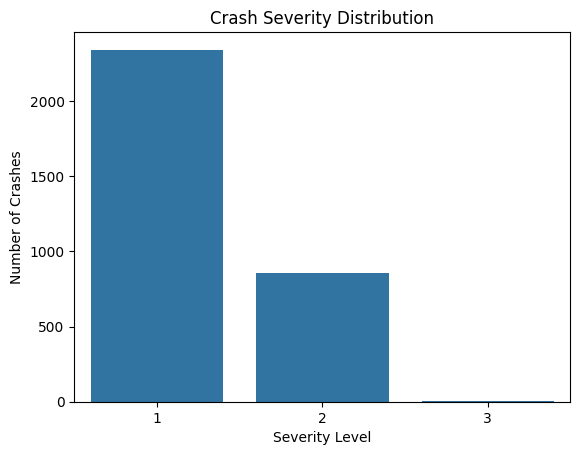

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=model_df["Severity_Score"])
plt.title("Crash Severity Distribution")
plt.xlabel("Severity Level")
plt.ylabel("Number of Crashes")
plt.show()

The crash severity distribution shows that most crashes are low severity (Level 1), fewer are moderate (Level 2), and very few are severe (Level 3), indicating a strongly imbalanced dataset.

Crahes by Hour

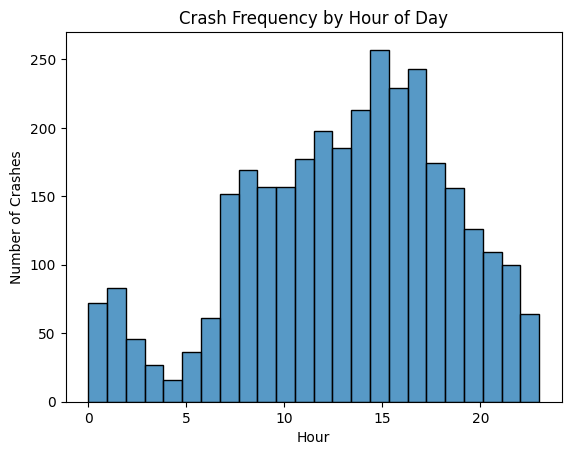

In [ ]:
sns.histplot(model_df["Hour"], bins=24)
plt.title("Crash Frequency by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Crashes")
plt.show()

Crashes by month

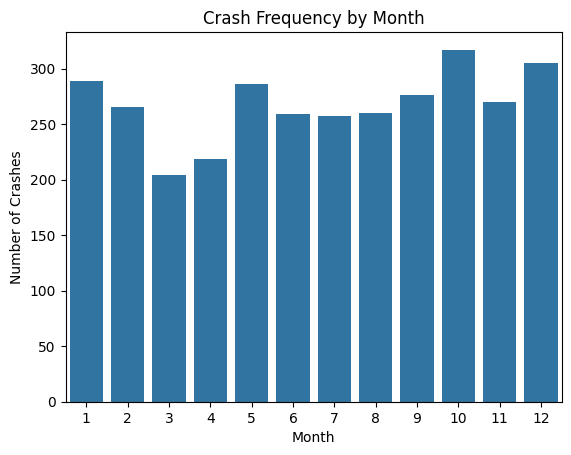

In [ ]:
sns.countplot(x=model_df["Month"])
plt.title("Crash Frequency by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crashes")
plt.show()

Hour vs Severity

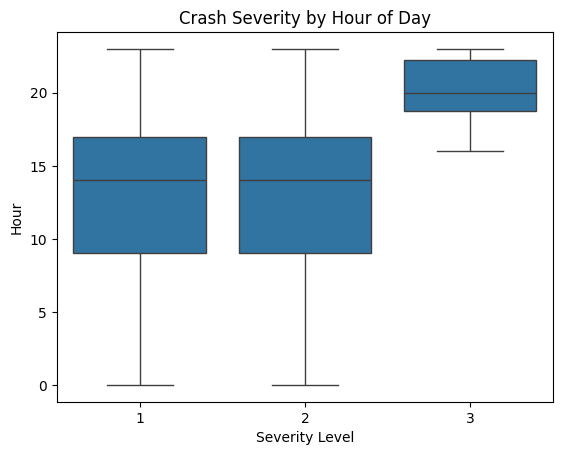

In [ ]:
sns.boxplot(x=model_df["Severity_Score"], y=model_df["Hour"])
plt.title("Crash Severity by Hour of Day")
plt.xlabel("Severity Level")
plt.ylabel("Hour")
plt.show()

Heatmap

Crash risk Heatmap

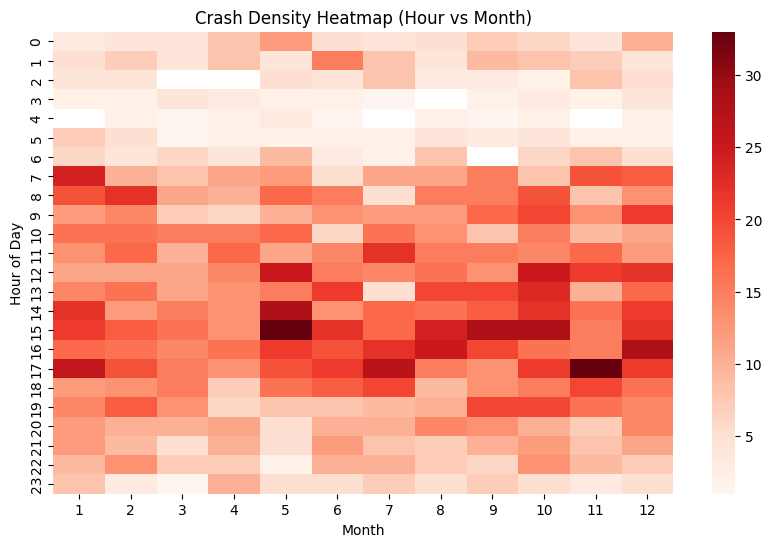

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = model_df.pivot_table(
    index="Hour",
    columns="Month",
    values="Severity_Score",
    aggfunc="count"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="Reds")

plt.title("Crash Density Heatmap (Hour vs Month)")
plt.xlabel("Month")
plt.ylabel("Hour of Day")

plt.show()

Crash Severity by Hour

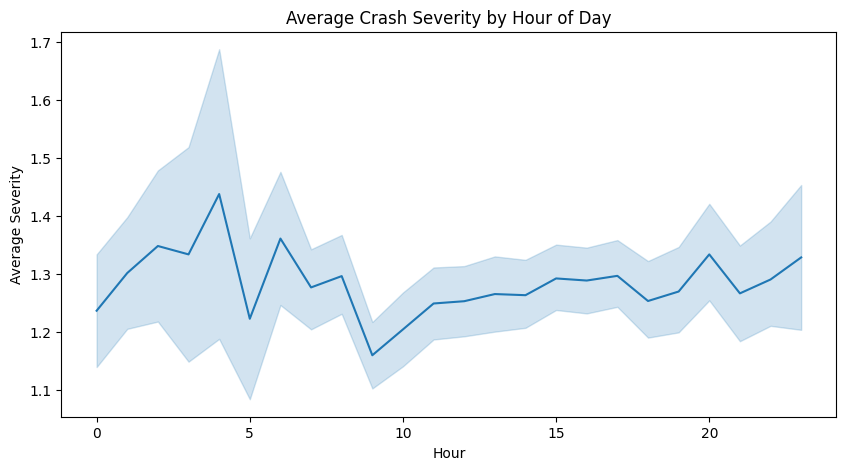

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=model_df,
    x="Hour",
    y="Severity_Score",
    estimator="mean"
)

plt.title("Average Crash Severity by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Severity")

plt.show()

Weekend vs Weekday Crash Comparison

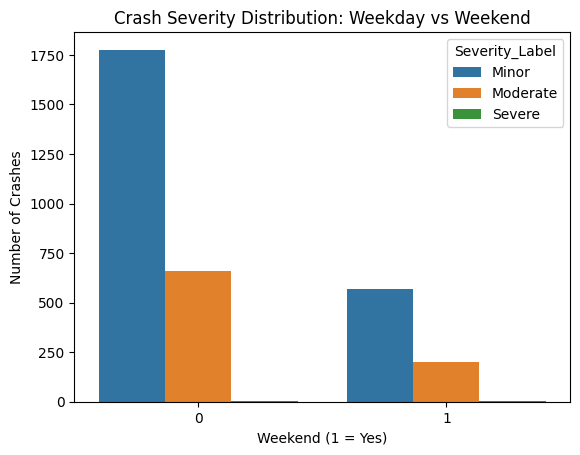

In [ ]:
severity_labels = {
    1: "Minor",
    2: "Moderate",
    3: "Severe"
}

model_df["Severity_Label"] = model_df["Severity_Score"].map(severity_labels)

sns.countplot(
    data=model_df,
    x="Is_Weekend",
    hue="Severity_Label"
)

plt.title("Crash Severity Distribution: Weekday vs Weekend")
plt.xlabel("Weekend (1 = Yes)")
plt.ylabel("Number of Crashes")

plt.show()

Crash Distribution by Hour

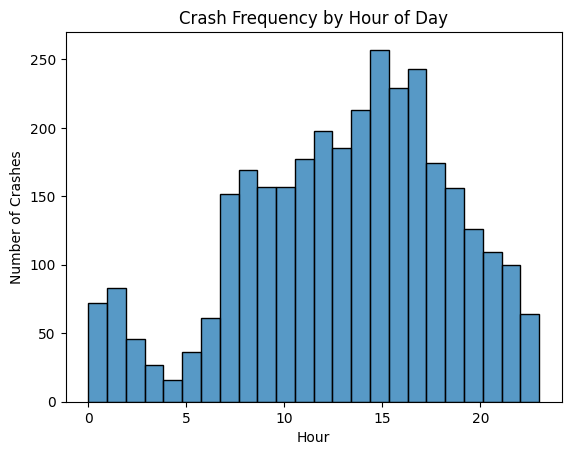

In [ ]:
sns.histplot(model_df["Hour"], bins=24)

plt.title("Crash Frequency by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Number of Crashes")

plt.show()

Crash Severity vs Hour of Day

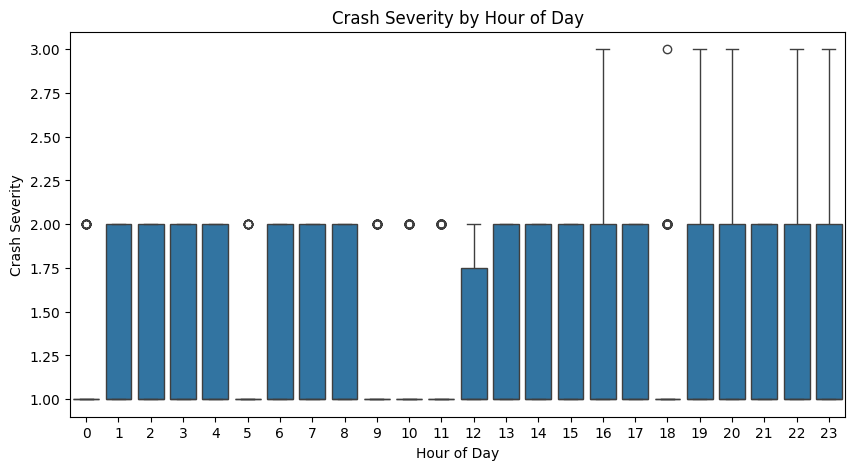

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.boxplot(
    data=model_df,
    x="Hour",
    y="Severity_Score"
)

plt.title("Crash Severity by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Crash Severity")

plt.show()

Average Seveity by Hour